In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [5]:
df = pd.read_csv(
    "../data/processed/churn_cleaned.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("Rows, Columns:", df.shape)

df.info()

Rows, Columns: (7032, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling

In [7]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=[
        "0-1 Year",
        "1-2 Years",
        "2-4 Years",
        "4+ Years"
    ]
)

df["TenureGroup"].value_counts()

TenureGroup
4+ Years     2239
0-1 Year     2175
2-4 Years    1594
1-2 Years    1024
Name: count, dtype: int64

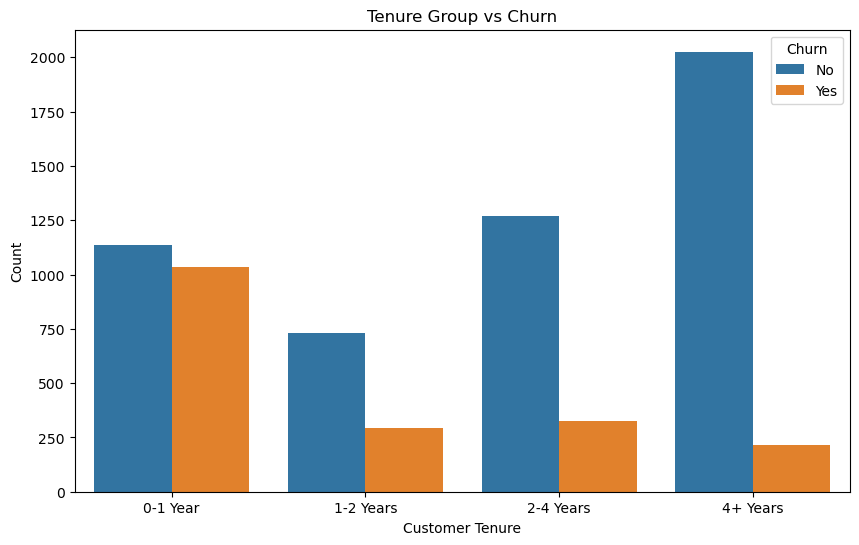

In [8]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="TenureGroup",
    hue="Churn"
)

plt.title("Tenure Group vs Churn")
plt.xlabel("Customer Tenure")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

In [9]:
df["SpendingGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0,35,70,120],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

df["SpendingGroup"].value_counts()

SpendingGroup
High      3581
Low       1729
Medium    1722
Name: count, dtype: int64

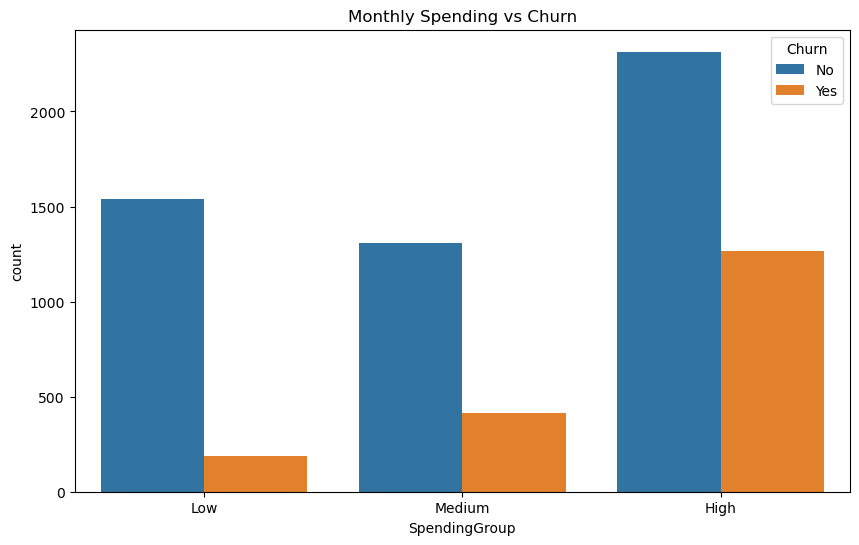

In [10]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="SpendingGroup",
    hue="Churn"
)

plt.title("Monthly Spending vs Churn")

plt.show()

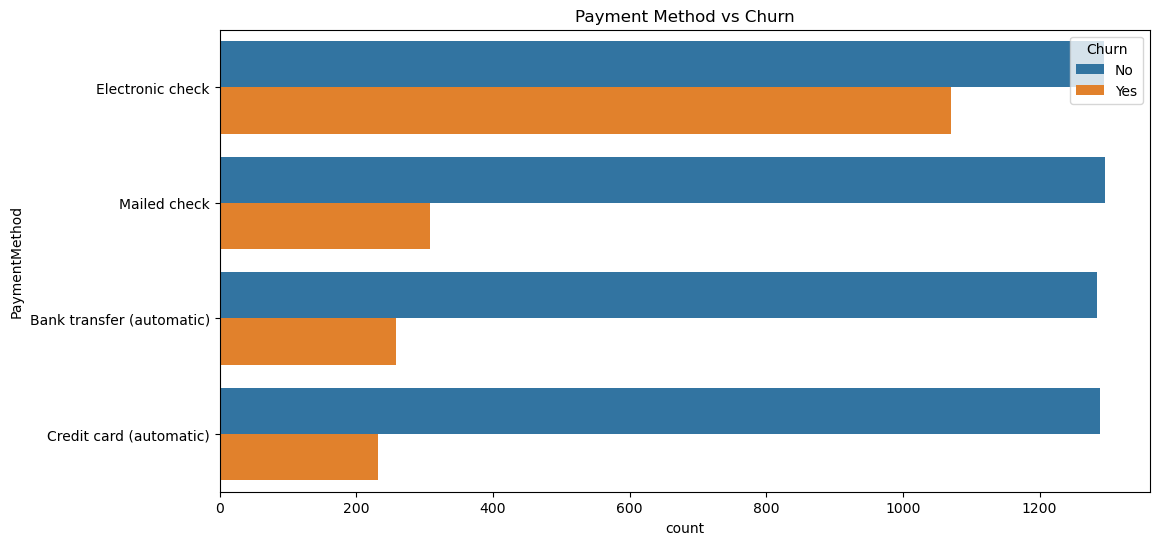

In [11]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="PaymentMethod",
    hue="Churn"
)

plt.title("Payment Method vs Churn")

plt.show()

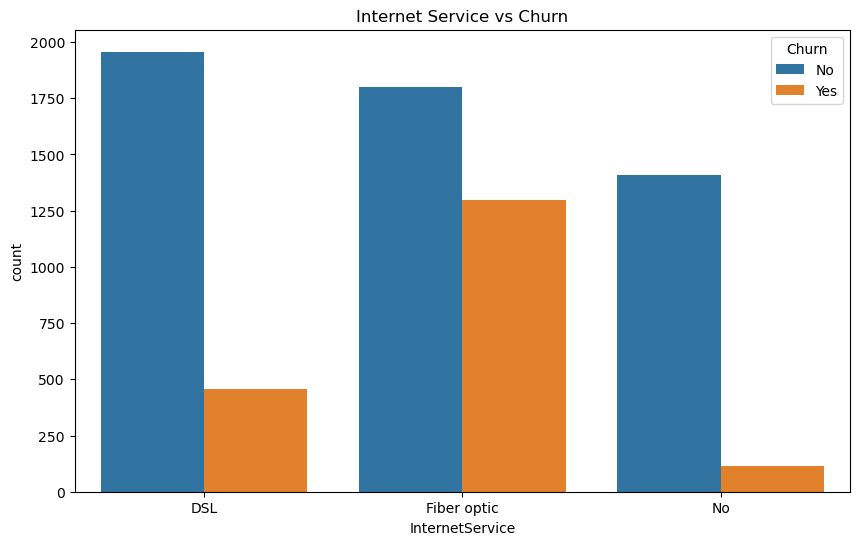

In [12]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Churn")

plt.show()

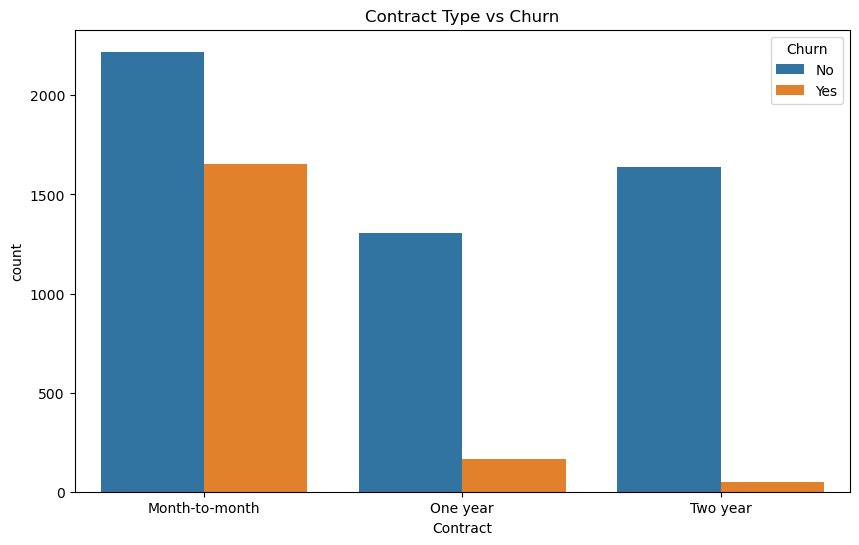

In [13]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Churn")

plt.show()

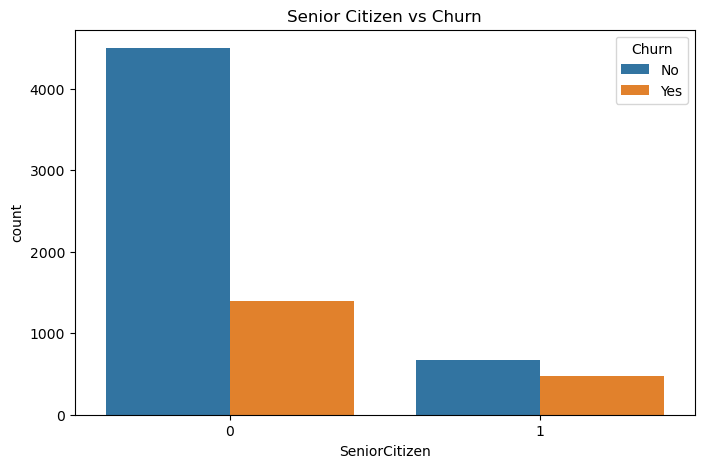

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Senior Citizen vs Churn")

plt.show()

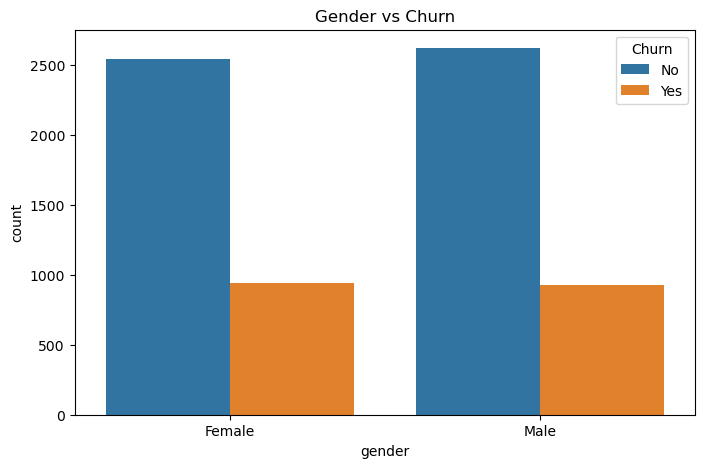

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Gender vs Churn")

plt.show()

In [16]:
churn_rate = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
)*100

print(churn_rate.round(2))

Churn           No    Yes
TenureGroup              
0-1 Year     52.32  47.68
1-2 Years    71.29  28.71
2-4 Years    79.61  20.39
4+ Years     90.49   9.51


In [17]:
df.to_csv(
    "../data/processed/churn_segmented.csv",
    index=False
)